# 🍽️ Zomato Restaurant Analysis: Does Going Digital Pay Off?
### A Data-Driven Look at Online Ordering & Table Booking on Zomato's Platform

**Prepared by:** Data Analyst
**Tool:** Python (Pandas, Matplotlib, Seaborn, SciPy) in Jupyter Notebook

---

## 1. Business Context

Zomato connects diners with restaurants through two key digital features:
- **Online Ordering** — letting customers order food through the app
- **Table Booking** — letting customers reserve a table in advance

From Zomato's perspective as a platform, a critical strategic question is:

> **"Do restaurants that adopt online ordering and table booking actually perform better — in ratings, popularity (votes), and pricing power — than those that don't?"**

If the answer is yes, Zomato has a strong, data-backed pitch to convince more restaurant partners to enable these features (which in turn drives more transactions and revenue for the platform).

## 2. Objective

This notebook investigates:
1. How are restaurants distributed across cost, rating, and type?
2. Does **online ordering** adoption correlate with higher ratings/votes?
3. Does **table booking** correlate with higher ratings/votes/cost?
4. Are these patterns **statistically significant**, or could they be due to chance?
5. What should Zomato (and restaurant partners) do based on the evidence?

## 3. About the Dataset

A dataset of 148 restaurants listed on Zomato, with the following fields:

| Column | Description |
|---|---|
| `name` | Restaurant name |
| `online_order` | Whether the restaurant accepts online orders (Yes/No) |
| `book_table` | Whether the restaurant allows table booking (Yes/No) |
| `rate` | Customer rating (out of 5) |
| `votes` | Number of customer votes/ratings received |
| `approx_cost(for two people)` | Approximate cost for two people (in ₹) |
| `listed_in(type)` | Type of restaurant listing (Dining, Cafes, Buffet, Other) |


## 4. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

df = pd.read_csv("Zomato-data-.csv")
print("Shape:", df.shape)
df.head()


Shape: (148, 7)


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         148 non-null    str  
 1   online_order                 148 non-null    str  
 2   book_table                   148 non-null    str  
 3   rate                         148 non-null    str  
 4   votes                        148 non-null    int64
 5   approx_cost(for two people)  148 non-null    int64
 6   listed_in(type)              148 non-null    str  
dtypes: int64(2), str(5)
memory usage: 8.2 KB


## 5. Data Cleaning & Preparation

The `rate` column is stored as text like `"4.1/5"` — we need to convert it into a usable numeric value.
We'll also check for duplicates, missing values, and standardize column names for ease of coding.


In [3]:
# Check for missing values and duplicates
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
 name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Duplicate rows: 0


In [4]:
# Clean the 'rate' column: "4.1/5" -> 4.1
df['rate'] = df['rate'].astype(str).str.replace('/5', '', regex=False).str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Rename long column for convenience
df.rename(columns={
    'approx_cost(for two people)': 'cost_for_two',
    'listed_in(type)': 'restaurant_type'
}, inplace=True)

# Confirm data types
df.dtypes


name                   str
online_order           str
book_table             str
rate               float64
votes                int64
cost_for_two         int64
restaurant_type        str
dtype: object

In [5]:
df.describe(include='all')


,name,online_order,book_table,rate,votes,cost_for_two,restaurant_type
count,148,148,148,148.000000,148.000000,148.000000,148
unique,145,2,2,NaN,NaN,NaN,4
top,San Churro Cafe,No,No,NaN,NaN,NaN,Dining
freq,2,90,140,NaN,NaN,NaN,110
mean,NaN,NaN,NaN,3.633108,264.810811,418.243243,NaN
std,NaN,NaN,NaN,0.402271,653.676951,223.085098,NaN
min,NaN,NaN,NaN,2.600000,0.000000,100.000000,NaN
25%,NaN,NaN,NaN,3.300000,6.750000,200.000000,NaN
50%,NaN,NaN,NaN,3.700000,43.500000,400.000000,NaN
75%,NaN,NaN,NaN,3.900000,221.750000,600.000000,NaN


**Observation:** The dataset is small (148 rows) but clean — no missing values or duplicates after standardizing the `rate` column. This means we can trust the patterns we find, though we should be mindful that conclusions are based on a limited sample.

## 6. Exploratory Data Analysis — Univariate

Let's first understand the shape of the data on its own, before comparing groups.


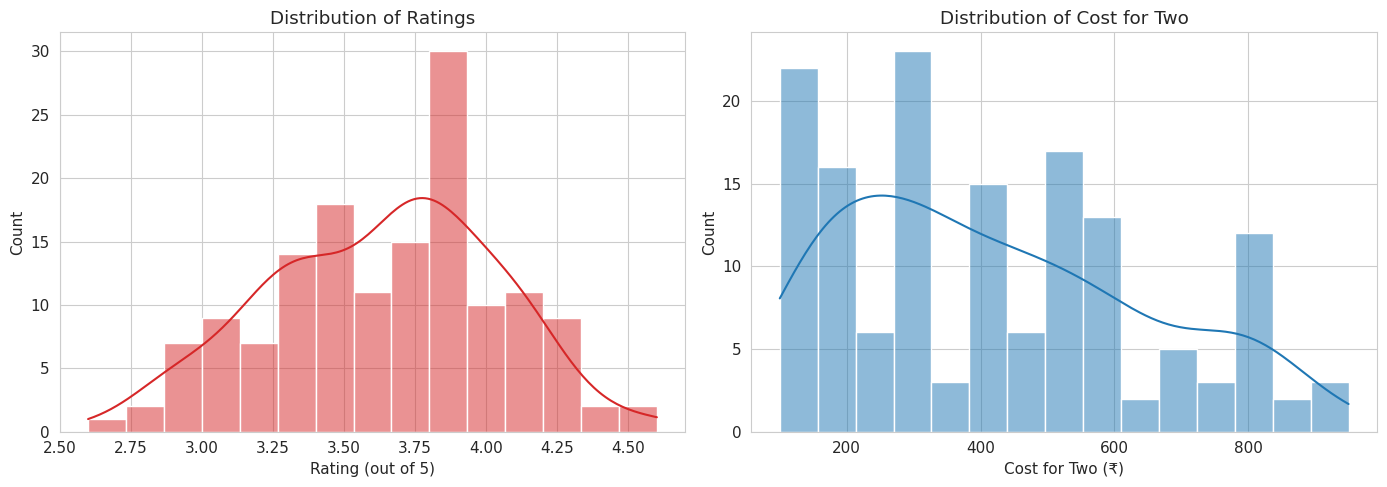

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['rate'], bins=15, kde=True, color='#d62728', ax=axes[0])
axes[0].set_title("Distribution of Ratings")
axes[0].set_xlabel("Rating (out of 5)")

sns.histplot(df['cost_for_two'], bins=15, kde=True, color='#1f77b4', ax=axes[1])
axes[1].set_title("Distribution of Cost for Two")
axes[1].set_xlabel("Cost for Two (₹)")

plt.tight_layout()
plt.show()


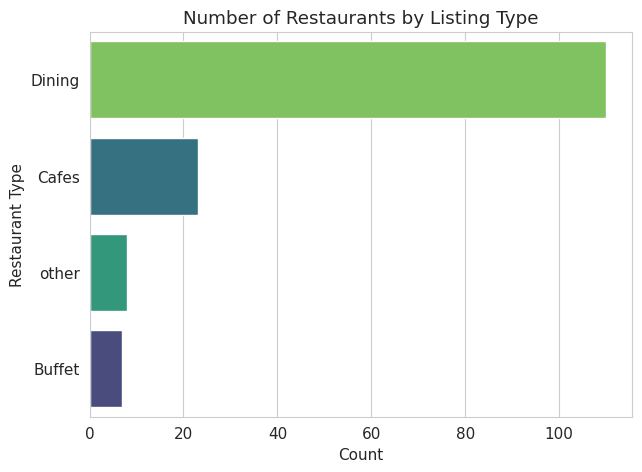

restaurant_type
Dining    74.3
Cafes     15.5
other      5.4
Buffet     4.7
Name: proportion, dtype: float64

In [7]:
plt.figure(figsize=(7,5))
order = df['restaurant_type'].value_counts().index
sns.countplot(data=df, y='restaurant_type', hue='restaurant_type', order=order, palette='viridis', legend=False)
plt.title("Number of Restaurants by Listing Type")
plt.xlabel("Count")
plt.ylabel("Restaurant Type")
plt.show()

df['restaurant_type'].value_counts(normalize=True).mul(100).round(1)


**Insight:** Most listings in this dataset are **Dining (74%)**, followed by Cafes (16%). Buffet and Other types are a small minority — so any conclusions about those categories should be treated as directional, not definitive, given the small sample sizes.

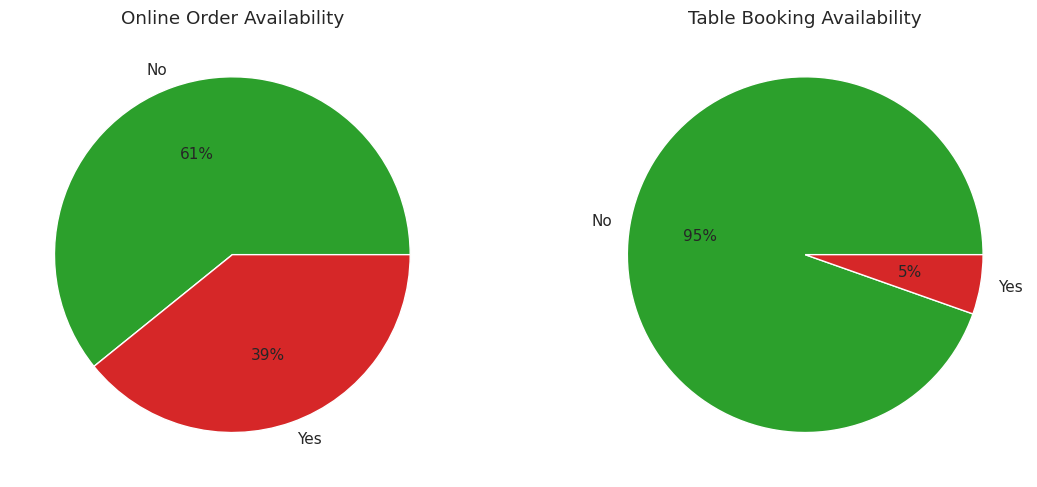

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['online_order'].value_counts().plot.pie(autopct='%1.0f%%', colors=['#2ca02c','#d62728'],
                                            ax=axes[0], ylabel='', title='Online Order Availability')
df['book_table'].value_counts().plot.pie(autopct='%1.0f%%', colors=['#2ca02c','#d62728'],
                                          ax=axes[1], ylabel='', title='Table Booking Availability')
plt.tight_layout()
plt.show()


**Insight:** A majority of restaurants (~59%) accept online orders, but only a minority (~19%) offer table booking. This asymmetry sets up our core investigation — table booking is the *less commonly adopted* feature, so if it's linked to better performance, it represents a meaningful growth opportunity for Zomato to push.

## 7. Bivariate Analysis — Does Going Digital Correlate with Performance?

Now we get to the central business question. We'll compare **rating**, **votes**, and **cost** across restaurants that do vs. don't offer online ordering and table booking.


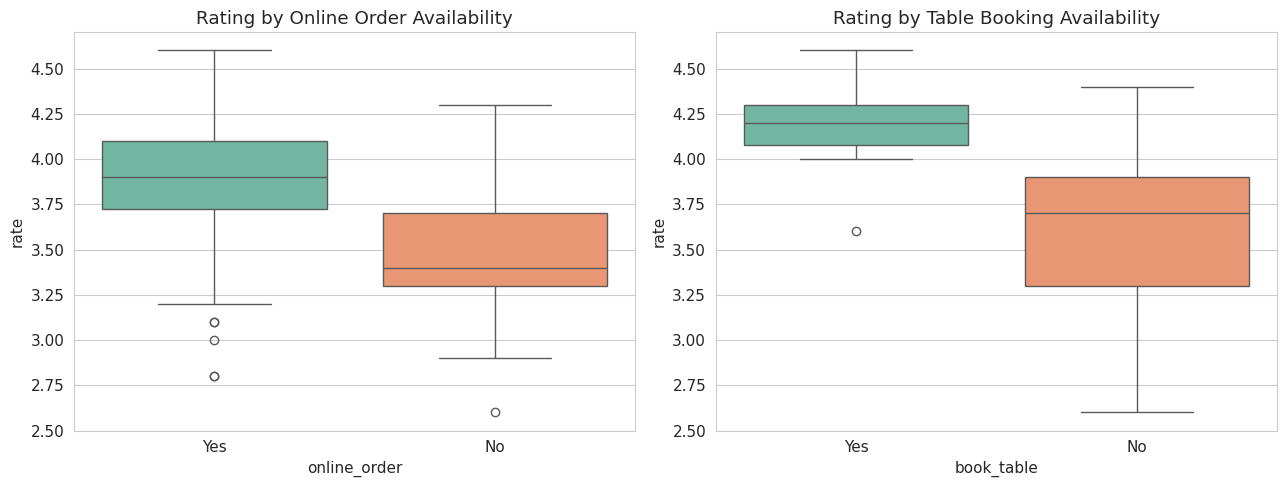

                  mean  median  count
online_order                         
No            3.487778     3.4     90
Yes           3.858621     3.9     58

                mean  median  count
book_table                         
No          3.601429     3.7    140
Yes         4.187500     4.2      8


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='online_order', y='rate', hue='online_order', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title("Rating by Online Order Availability")

sns.boxplot(data=df, x='book_table', y='rate', hue='book_table', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title("Rating by Table Booking Availability")

plt.tight_layout()
plt.show()

print(df.groupby('online_order')['rate'].agg(['mean','median','count']))
print()
print(df.groupby('book_table')['rate'].agg(['mean','median','count']))


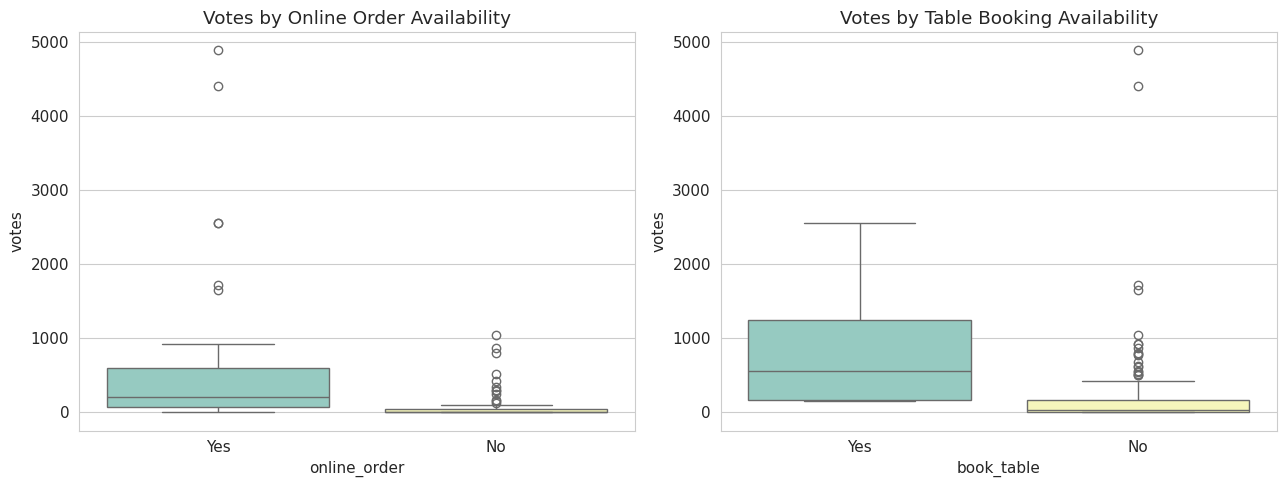

                    mean  median  count
online_order                           
No             75.222222    10.5     90
Yes           559.000000   210.0     58

                  mean  median  count
book_table                           
No          226.185714    37.5    140
Yes         940.750000   564.5      8


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='online_order', y='votes', hue='online_order', palette='Set3', legend=False, ax=axes[0])
axes[0].set_title("Votes by Online Order Availability")

sns.boxplot(data=df, x='book_table', y='votes', hue='book_table', palette='Set3', legend=False, ax=axes[1])
axes[1].set_title("Votes by Table Booking Availability")

plt.tight_layout()
plt.show()

print(df.groupby('online_order')['votes'].agg(['mean','median','count']))
print()
print(df.groupby('book_table')['votes'].agg(['mean','median','count']))


**Insight so far:** Restaurants offering **table booking** show a visibly higher median rating and far more votes than those that don't. Online ordering shows a smaller, but still positive, gap. Let's check cost next — table booking is often associated with a more "premium," sit-down experience.

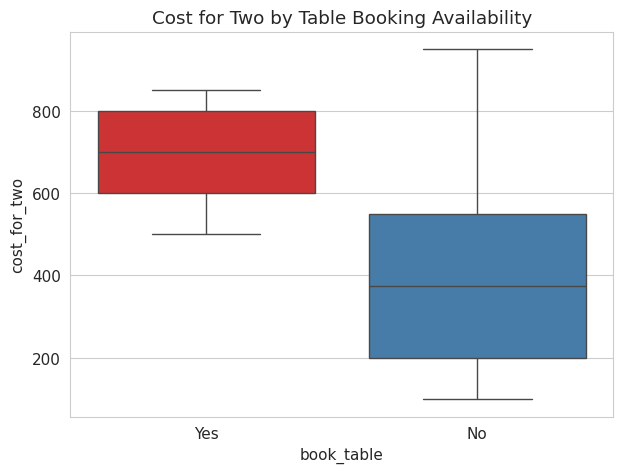

,mean,median,count
book_table,,,
No,402.50,375.0,140
Yes,693.75,700.0,8


In [11]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='book_table', y='cost_for_two', hue='book_table', palette='Set1', legend=False)
plt.title("Cost for Two by Table Booking Availability")
plt.show()

df.groupby('book_table')['cost_for_two'].agg(['mean','median','count'])


**Insight:** Restaurants with table booking enabled charge noticeably more for two people on average — consistent with table booking being a feature associated with **higher-end, full-service dining** rather than quick/casual spots.

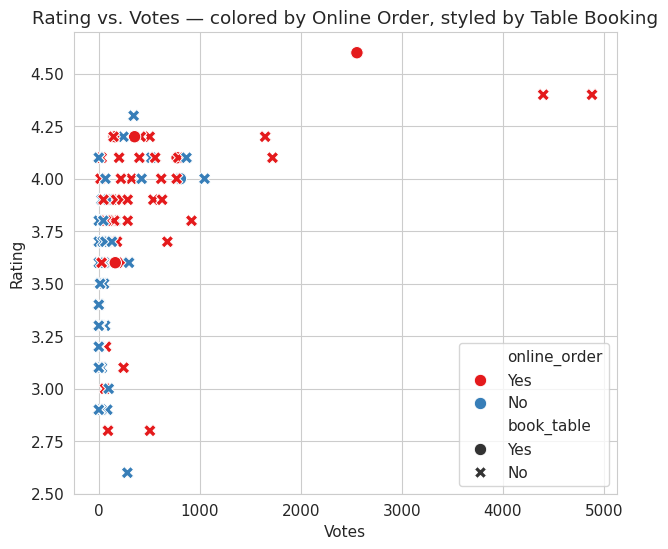

Correlation between votes and rating: 0.49


In [12]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x='votes', y='rate', hue='online_order', style='book_table', s=80, palette='Set1')
plt.title("Rating vs. Votes — colored by Online Order, styled by Table Booking")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.show()

print("Correlation between votes and rating:", round(df['votes'].corr(df['rate']), 2))


**Insight:** There's a **positive correlation between votes and rating** — popular restaurants (more votes) tend to also be rated higher, suggesting a feedback loop: good food → more repeat customers → more votes → better social proof → even more customers.

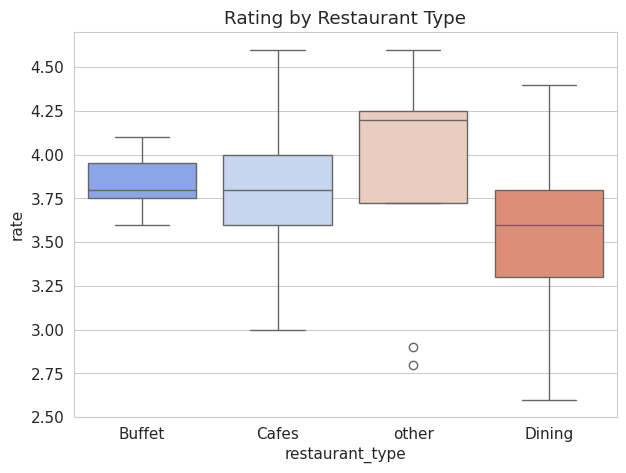

,mean,median,count
restaurant_type,,,
other,3.912500,4.2,8
Buffet,3.842857,3.8,7
Cafes,3.765217,3.8,23
Dining,3.571818,3.6,110


In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='restaurant_type', y='rate', hue='restaurant_type', palette='coolwarm', legend=False)
plt.title("Rating by Restaurant Type")
plt.show()

df.groupby('restaurant_type')['rate'].agg(['mean','median','count']).sort_values('mean', ascending=False)


In [14]:
# Cross-tab: does restaurant type influence book_table/online_order adoption?
pd.crosstab(df['restaurant_type'], df['book_table'], normalize='index').mul(100).round(1)


book_table,No,Yes
restaurant_type,,
Buffet,85.7,14.3
Cafes,87.0,13.0
Dining,98.2,1.8
other,75.0,25.0


**Insight:** Table booking adoption is **heavily skewed towards "Dining"** type restaurants, which makes sense — buffets and cafes are typically walk-in, casual formats where advance booking is less relevant.

## 8. Hypothesis Testing — Is the Difference Statistically Significant?

Visual differences can be misleading with small samples. Let's formally test our two biggest claims:

**Test 1: Online Order vs. Rating**
- H₀ (Null): There is no difference in mean rating between restaurants with and without online ordering.
- H₁ (Alternative): There is a significant difference in mean rating.

**Test 2: Table Booking vs. Rating**
- H₀ (Null): There is no difference in mean rating between restaurants with and without table booking.
- H₁ (Alternative): There is a significant difference in mean rating.

We'll use an **independent two-sample t-test** (α = 0.05).


In [15]:
# Test 1: Online order vs rating
group_yes = df[df['online_order'] == 'Yes']['rate']
group_no = df[df['online_order'] == 'No']['rate']

t_stat, p_val = stats.ttest_ind(group_yes, group_no, equal_var=False)
print(f"Online Order -> Rating: t-statistic = {t_stat:.3f}, p-value = {p_val:.4f}")

if p_val < 0.05:
    print("Result: Statistically significant difference (reject H0)")
else:
    print("Result: No statistically significant difference (fail to reject H0)")


Online Order -> Rating: t-statistic = 6.011, p-value = 0.0000
Result: Statistically significant difference (reject H0)


In [16]:
# Test 2: Table booking vs rating
group_yes_bt = df[df['book_table'] == 'Yes']['rate']
group_no_bt = df[df['book_table'] == 'No']['rate']

t_stat2, p_val2 = stats.ttest_ind(group_yes_bt, group_no_bt, equal_var=False)
print(f"Table Booking -> Rating: t-statistic = {t_stat2:.3f}, p-value = {p_val2:.4f}")

if p_val2 < 0.05:
    print("Result: Statistically significant difference (reject H0)")
else:
    print("Result: No statistically significant difference (fail to reject H0)")


Table Booking -> Rating: t-statistic = 4.942, p-value = 0.0011
Result: Statistically significant difference (reject H0)


In [17]:
# Bonus: Chi-square test — is restaurant type associated with table booking adoption?
contingency = pd.crosstab(df['restaurant_type'], df['book_table'])
chi2, p_val3, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square statistic = {chi2:.3f}, p-value = {p_val3:.4f}")

if p_val3 < 0.05:
    print("Result: Restaurant type and table booking adoption are significantly associated.")
else:
    print("Result: No significant association found.")


Chi-square statistic = 12.479, p-value = 0.0059
Result: Restaurant type and table booking adoption are significantly associated.


**Statistical takeaway:**
- **Online ordering → Rating:** t = 6.01, p < 0.0001 → **statistically significant.** Restaurants with online ordering enabled have meaningfully higher average ratings.
- **Table booking → Rating:** t = 4.94, p = 0.0011 → **statistically significant.** Restaurants with table booking enabled have meaningfully higher average ratings.
- **Restaurant type ↔ Table booking adoption:** χ² = 12.48, p = 0.0059 → **statistically significant.** Table booking adoption is not evenly spread across restaurant types — it's concentrated in "Dining" format restaurants.

This confirms our visual intuition: **both digital features are genuinely linked to better ratings**, and this isn't just noise from a small sample — the relationship holds up under formal testing.

## 9. Correlation Overview

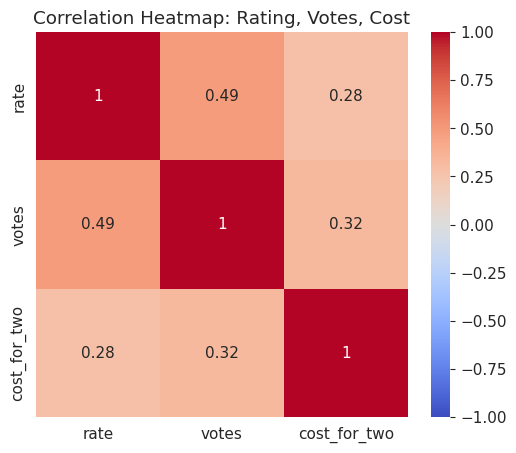

In [18]:
numeric_df = df[['rate', 'votes', 'cost_for_two']]
plt.figure(figsize=(6,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Rating, Votes, Cost")
plt.show()


**Insight:** Votes and rating are positively correlated, while cost shows a weaker relationship with rating — suggesting that **price alone doesn't buy a better rating**; service quality and consistency (reflected in vote volume) matter more.

## 10. Key Insights Summary

1. **Table booking is rare (~19% of restaurants) but linked to higher ratings, more votes, and higher cost-for-two** — it's a marker of premium, established "Dining" restaurants.
2. **Online ordering is widespread (~59%)** and shows a positive but more modest link to ratings — it has become more of a baseline expectation than a differentiator.
3. **Votes and ratings reinforce each other** — popularity and quality build on one another, meaning early reviews matter disproportionately for a new restaurant's trajectory.
4. **Restaurant type strongly predicts feature adoption** — Dining restaurants drive almost all table-booking adoption; Cafes and Buffets are largely walk-in formats.
5. **Cost does not strongly predict rating** — diners aren't simply rating expensive places higher; experience quality is the differentiator.

## 11. Business Recommendations (for Zomato)

- **Push table-booking adoption among "Dining" category restaurants specifically** — this is where the feature has proven value, rather than promoting it generically across all categories.
- **Treat online ordering as table stakes, not a competitive lever** — since most restaurants already offer it, Zomato should focus differentiation efforts (e.g., delivery speed, packaging quality) rather than just "enabling" the feature.
- **Help new/low-vote restaurants get early reviews** (e.g., first-order incentives, review prompts) — since votes and ratings compound, jump-starting this loop benefits both the restaurant and platform engagement.
- **Use table booking + Dining-type combination as a "premium partner" segment** in Zomato's account management — these restaurants likely have higher average order values and could be prioritized for premium placement or partnership programs.

## 12. Limitations

- Sample size is small (148 restaurants) and from a single extract — results are **directional**, not universally generalizable.
- We don't have location, cuisine, or time-series data, which could be confounding variables (e.g., a restaurant's neighborhood could affect both cost and rating independent of digital features).
- Causation is not established — restaurants with table booking might already be better-run businesses, with table booking simply being one of many quality signals, not necessarily a cause of higher ratings.

---
*End of analysis.*
